# AutoPrice Engine - Разработка модели экспресс-оценки стоимости выкупа автомобиля для компании AutoValue AI

### Постановка задачи
Необходимо разработать интеллектуальную систему оценки стоимости подержанных автомобилей для компании AutoValue AI. Модель должна предсказывать рыночную стоимость автомобиля в рублях на основе его технических характеристик, истории эксплуатации и региона продажи.
Система заменит ручной труд 50 экспертов-оценщиков и обеспечит мгновенную (менее 1 секунды) выдачу оффера клиенту прямо в мобильном приложении. Ошибка модели напрямую влияет на финансовый результат компании: переоценка автомобиля ведёт к прямым убыткам при перепродаже, а недооценка — к потере клиента в пользу конкурентов.

### Описание данных
Целевая переменная: price_rub — непрерывная числовая переменная, рыночная стоимость автомобиля в рублях.

Вводные данные: единый датасет из 8 000 исторических сделок (ds_s16_train_data.csv)
Тестовая выборка: ds_s16_test_data.csv — 2 000 записей, используется исключительно для финальной оценки модели. Не применяется ни на одном из этапов обучения или подбора гиперпараметров.

### Модели

В рамках проекта проводится турнир трёх библиотек градиентного бустинга — наиболее эффективного класса алгоритмов для табличных данных смешанного типа:

XGBoost — классический градиентный бустинг с гибкой регуляризацией (gamma, reg_lambda, reg_alpha)
CatBoost — специализирован для категориальных признаков, обрабатывает их нативно без предварительного кодирования
LightGBM — листовой рост деревьев, высокая скорость обучения, эффективен на больших выборках

Каждая модель проходит два этапа:

Базовое обучение — дефолтные или минимально настроенные параметры, для честного первичного сравнения
Оптимизация гиперпараметров — автоматический подбор через Optuna (байесовская оптимизация) в заданных диапазонах

Итоговая продакшн-модель выбирается по совокупности стандартных и бизнес-метрик.

### Оценка качества

Планируется двухуровневая система оценки.

Стандартные метрики ML:

RMSE — среднеквадратичная ошибка, штрафует за крупные промахи
MAE — средняя абсолютная ошибка в рублях, интуитивно понятна бизнесу
R² — доля объяснённой дисперсии, показывает общее качество модели

Бизнес-метрики AutoValue AI:

Overpricing Rate — доля сделок, где модель завысила цену более чем на 20%. Допустимый уровень должен быть минимальным: каждый такой случай — прямой финансовый убыток
Underpricing Loss — суммарная упущенная выгода по сделкам с занижением цены более чем на 20%. Отражает потери доли рынка из-за неконкурентных офферов

Финальная модель выбирается на основе баланса между двумя бизнес-метриками: допустимо незначительно ухудшить одну из них ради существенного улучшения другой. Дополнительно проводится анализ систематических ошибок по маркам автомобилей и регионам, чтобы исключить склонность модели к переоценке или недооценке конкретных сегментов.

### Загрузка необходимых библиотек

In [1]:
# Соберем все необходимые зависимости 

requirements = """
alembic==1.18.4
anyio==4.12.1
appnope==0.1.4
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.1.0
attrs==25.4.0
babel==2.17.0
beautifulsoup4==4.14.3
bleach==6.3.0
catboost==1.2.10
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
cloudpickle==3.1.2
colorlog==6.10.1
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.19
decorator==5.2.1
defusedxml==0.7.1
dill==0.4.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.61.1
fqdn==1.5.1
graphviz==0.21
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.11
ipykernel==7.1.0
ipython==9.9.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.13.0
jsonpointer==3.0.0
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-lsp==2.3.0
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.4
jupyterlab==4.5.2
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
jupyterlab_widgets==3.0.16
kiwisolver==1.4.9
lark==1.3.1
lightgbm==4.6.0
llvmlite==0.47.0
Mako==1.3.10
MarkupSafe==3.0.3
matplotlib==3.10.8
matplotlib-inline==0.2.1
mistune==3.2.0
mlxtend==0.24.0
narwhals==2.21.0
nbclient==0.10.4
nbconvert==7.16.6
nbformat==5.10.4
nest-asyncio==1.6.0
notebook==7.5.2
notebook_shim==0.2.4
numba==0.65.1
numpy==2.4.4
optuna==4.8.0
packaging==25.0
pandas==3.0.0
pandocfilters==1.5.1
parso==0.8.5
pexpect==4.9.0
phik==0.12.5
pillow==12.1.0
platformdirs==4.5.1
plotly==6.7.0
prometheus_client==0.24.1
prompt_toolkit==3.0.52
psutil==7.2.1
ptyprocess==0.7.0
pure_eval==0.2.3
pycparser==2.23
Pygments==2.19.2
pyparsing==3.3.2
python-dateutil==2.9.0.post0
python-json-logger==4.0.0
PyYAML==6.0.3
pyzmq==27.1.0
referencing==0.37.0
requests==2.32.5
rfc3339-validator==0.1.4
rfc3986-validator==0.1.1
rfc3987-syntax==1.1.0
rpds-py==0.30.0
scikit-learn==1.8.0
scipy==1.17.0
seaborn==0.13.2
Send2Trash==2.1.0
setuptools==80.9.0
shap==0.51.0
six==1.17.0
slicer==0.0.8
soupsieve==2.8.1
SQLAlchemy==2.0.49
stack-data==0.6.3
terminado==0.18.1
threadpoolctl==3.6.0
tinycss2==1.4.0
tornado==6.5.4
tqdm==4.67.3
traitlets==5.14.3
typing_extensions==4.15.0
tzdata==2025.3
uri-template==1.3.0
urllib3==2.6.3
wcwidth==0.2.14
webcolors==25.10.0
webencodings==0.5.1
websocket-client==1.9.0
widgetsnbextension==4.0.15
xgboost==3.2.0
"""

In [2]:
# Запишем зависимости в requirements.txt

with open("requirements.txt", "w") as f:
    f.write(requirements)

In [3]:
# Установим зависимости

!pip install -r requirements.txt -qqq 

In [4]:
# Зафиксируем константы

RANDOM_STATE = 42
N_TRIALS = 50
CURRENT_YEAR = 2024 # Так как данные в выборках в части года выпуска авто максимально за 2023 год, 
                    # предположим, что данные предоставлены в 2024 году

In [5]:
# Импортируем все необходимые библиотеки

import ssl
import time
import urllib.request
import math
import io
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import phik
import lightgbm as lgb
from phik import phik_matrix
from optuna.samplers import TPESampler
from scipy import stats
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

## EDA (Экспресс-анализ данных)**

### Загрузка данных

In [6]:
# Напишем функцию для загрузки файла локально или с сервера

def load_data(local_path, server_path):
    try:
        # Сначала пробуем локальный путь
        print(f"Пробуем загрузить из локального пути: {local_path}")
        df = pd.read_csv(local_path)
        print("Данные загружены из локального файла")
        return df
    
    except FileNotFoundError:
        # Если локальный файл не найден, пробуем серверный
        try:
            df = pd.read_csv(server_path)
            print("Данные загружены с сервера")
            return df
        except FileNotFoundError:
            print("Файл не найден ни в локально, ни на сервере")
            return None
        except Exception as e:
            print(f"Ошибка при загрузке с сервера: {e}")
            return None
    
    except Exception as e:
        print(f"Ошибка при загрузке из локального файла: {e}")
        return None

In [7]:
# Подготовим функционал по работе с неподтвержденными сертификатами

try:
    # Создаем небезопасный контекст
    ssl_context = ssl._create_unverified_context()
except AttributeError:
    # Альтернативный метод, если _create_unverified_context не работает
    ssl_context = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

# Создаем opener с нашим контекстом
https_handler = urllib.request.HTTPSHandler(context=ssl_context)
opener = urllib.request.build_opener(https_handler)
urllib.request.install_opener(opener)

In [8]:
# Укажем пути к файлам с данными

# Обучающая выборка

auto_value_train_local = '../datasets/ds_s16_train_data.csv'
auto_value_train_server = 'https://code.s3.yandex.net/datasets/ds_s16_train_data.csv'

# Тестовая выборка

auto_value_test_local = '../datasets/ds_s16_test_data.csv'
auto_value_test_server = 'https://code.s3.yandex.net/datasets/ds_s16_test_data.csv'

In [9]:
# Загружаем данные

df_auto_value_train = load_data(auto_value_train_local, auto_value_train_server)
df_auto_value_test = load_data(auto_value_test_local, auto_value_test_server)

Пробуем загрузить из локального пути: ../datasets/ds_s16_train_data.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_s16_test_data.csv
Данные загружены из локального файла


In [10]:
# Проверка

df_auto_value_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 812.6 KB


In [11]:
df_auto_value_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   str    
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   str    
 6   transmission        2000 non-null   str    
 7   color               2000 non-null   str    
 8   service_history     2000 non-null   str    
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   str    
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 203.3 KB


Вывод: данные загружены корректно и соответствуют описанию задачи. Мы получили два датасета: один для обучения и подбора гиперпараметров, второй - для независимой проверки финальной модели. Его отложим до момента получения финальной модели и не будем использовать ни в одном из этапов подготовки.
Оба датасета не содержат пропусков, типы данных соответствуют сути столбцов. 

### Краткий EDA

In [12]:
# Общая информация о распределении 

print("Базовая статистика price_rub")
df_auto_value_train['price_rub'].describe()

Базовая статистика price_rub


count    8.000000e+03
mean     6.836479e+05
std      2.649235e+05
min      9.500000e+04
25%      4.938570e+05
50%      6.638660e+05
75%      8.550560e+05
max      1.676525e+06
Name: price_rub, dtype: float64

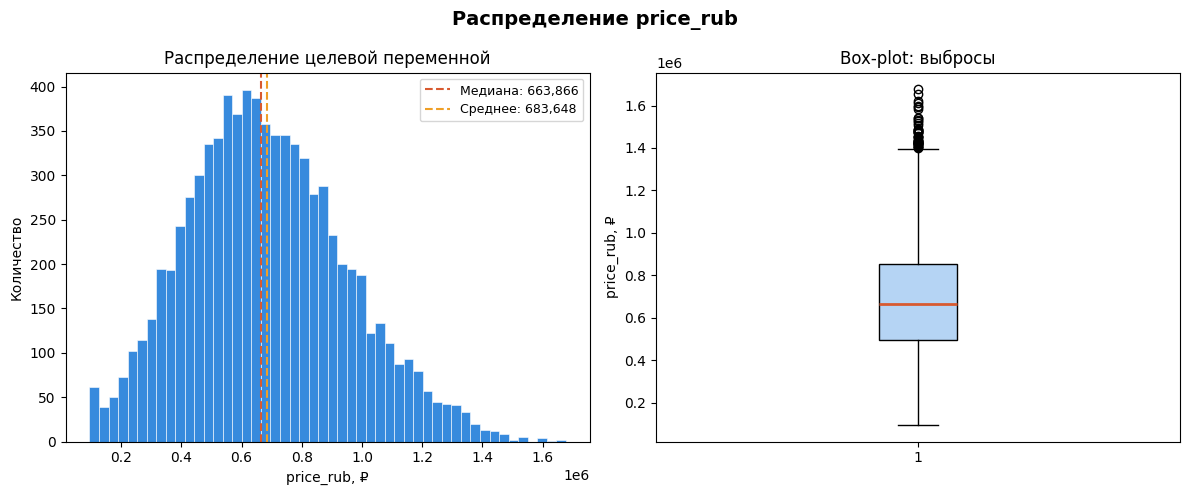

In [13]:
# Визуализация распределения

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Распределение price_rub', fontsize=14, fontweight='bold')

axes[0].hist(df_auto_value_train['price_rub'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.4)
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('price_rub, ₽')
axes[0].set_ylabel('Количество')
axes[0].axvline(df_auto_value_train['price_rub'].median(), color='#D85A30', linestyle='--',
                label=f"Медиана: {df_auto_value_train['price_rub'].median():,.0f}")
axes[0].axvline(df_auto_value_train['price_rub'].mean(), color='#EF9F27', linestyle='--',
                label=f"Среднее: {df_auto_value_train['price_rub'].mean():,.0f}")
axes[0].legend(fontsize=9)

axes[1].boxplot(df_auto_value_train['price_rub'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4'),
                medianprops=dict(color='#D85A30', linewidth=2))
axes[1].set_title('Box-plot: выбросы')
axes[1].set_ylabel('price_rub, ₽')

plt.tight_layout()
plt.show()

Вывод: распределение по целевой переменной близко к нормальном, с легкой правосторонней асимметрией.
Для целевой метрики можно использовать МАЕ. 
В датасете есть выбросы вверх, в небольшом количестве. Дополнительных методов обработки выбросов не потребуется

interval columns not set, guessing: ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported', 'price_rub']


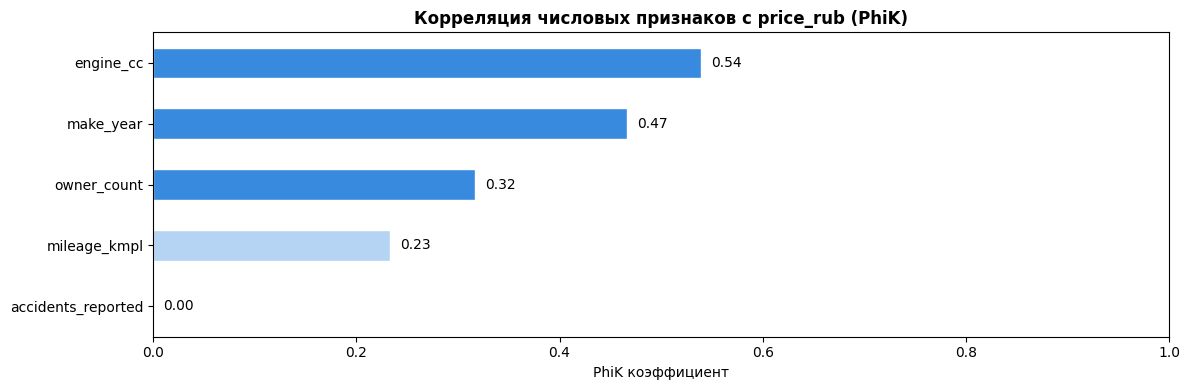

In [14]:
# Корелляция числовых признаков с целевой переменной

num_cols = ['make_year', 'mileage_kmpl', 'engine_cc',
            'owner_count', 'accidents_reported', 'price_rub']


phik_df = df_auto_value_train[num_cols].phik_matrix()
corr_vals = phik_df['price_rub'].drop('price_rub').sort_values()

fig, ax = plt.subplots(figsize=(12, 4))

# Цветом покажем силу связи
colors = ['#378ADD' if v >= 0.3 else '#B5D4F4' for v in corr_vals]
corr_vals.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Корреляция числовых признаков с price_rub (PhiK)',
             fontweight='bold')
ax.set_xlabel('PhiK коэффициент')
ax.set_xlim(0, 1)

for i, v in enumerate(corr_vals):
    ax.text(v + 0.01, i, f'{v:.2f}',
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

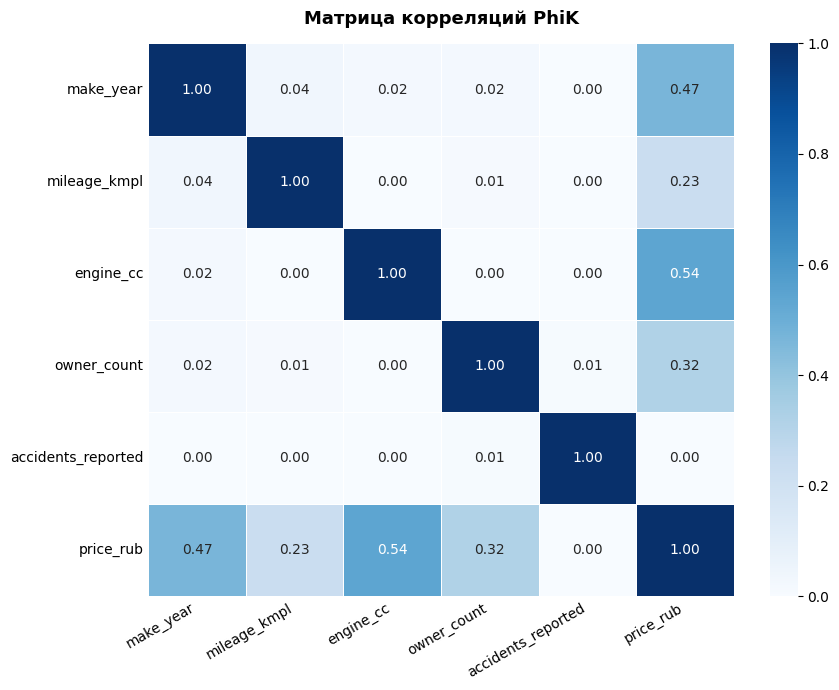

In [15]:
# Тепловая карта матрицы корелляции

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    phik_df,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10, 'weight': '500'},
)

ax.set_title('Матрица корреляций PhiK', fontsize=13, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

Выводы:

1. engine_cc - имеет самую сильную корелляцию с целевой переменной - чем больше объём, тем дороже
2. make_year - также имеет сильную корелляцию - чем новее авто, тем выше цена
3. owner_count - отрицательная корелляция - чем больше владельцев, тем дешевле
4. mileage_kmpl положительно коррелирует с ценой. Чем выше топливная эффективность, тем позитивнее это влияет на цену
5. accidents_reported - количество ДТП - практически, не имеет линейной корелляции с ценой. Также стоит учесть при составлении новых признаков, возможно, есть нелинейные зависимости

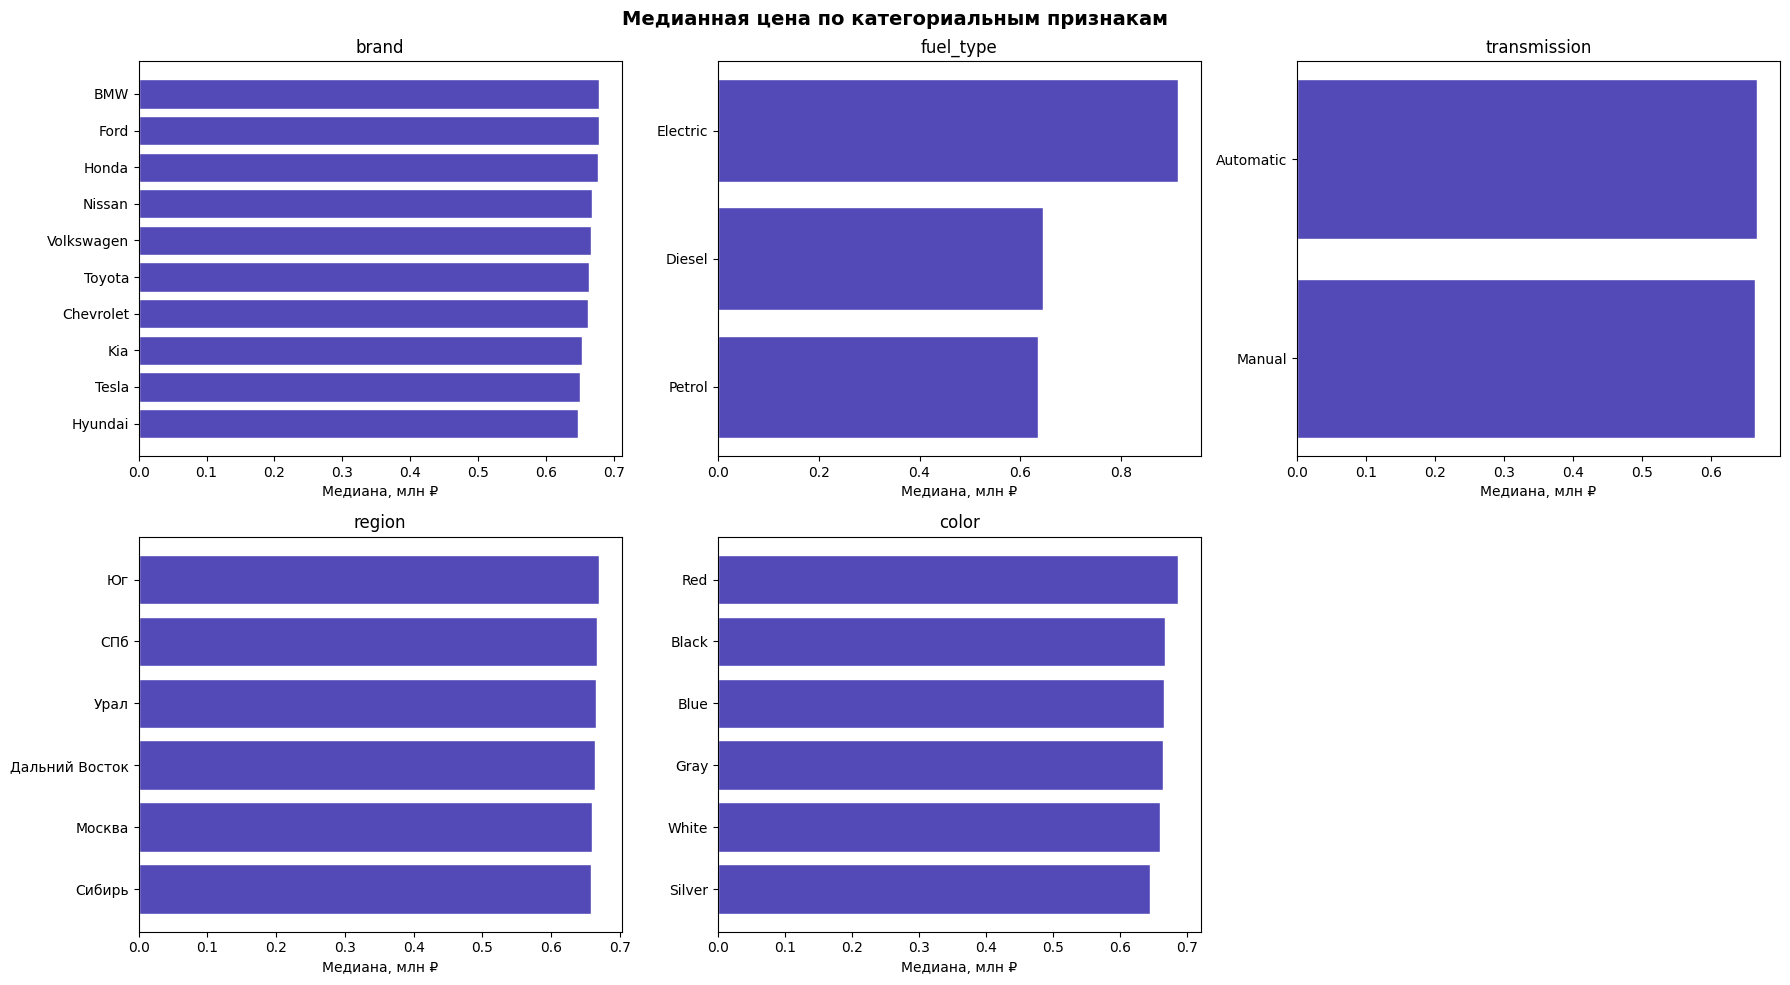

In [16]:
# Анализ категориальных признаков

cat_cols = ['brand', 'fuel_type', 'transmission', 'region', 'color']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Медианная цена по категориальным признакам', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    med = df_auto_value_train.groupby(col)['price_rub'].median().sort_values(ascending=False)
    if len(med) > 12:
        med = med.head(12)
    axes[i].barh(med.index, med.values / 1e6, color='#534AB7', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Медиана, млн ₽')
    axes[i].invert_yaxis()

axes[-1].axis('off')
plt.tight_layout()
plt.show()

Вывод: fuel_type — единственный категориальный признак с выраженным разрывом, который влияет на цену. Остальные категориальные признаки слабо влияют на цену

## **Предобработка**

###  Подготовка новых признаков

Для дальнейшей работы подготовим новые признаки:

1. Возраст автомобиля для интерпретации года выпуска
2. Пробег в год - как отношение общего пробега к возрасту - для интерпретации интенсивности использования
3. Аварийность в год - отношение числа ДТП для авто к возрасту - регулярность попадания в ДТП
4. Много владельцев * ДТП - покажет аккуратность использования, постоянные перепродажи и ДТП должны негативно влиять на цену
5. Флаг «Чистая история»: нет ДТП + один владелец + сервисная книжка - должно позитивно влиять на стоимость

Также удалим признак 'make_year' - мы учтем его в новом признаке Возраст автомобиля

In [17]:
# Напишем функцию создания признаков, которую сможем применять к любому датасету

def engineer_features(df):
    df = df.copy()

    df['car_age'] = CURRENT_YEAR - df['make_year'] # Возраст авто
    df['accidents_per_year'] = df['accidents_reported'] / (df['car_age'] + 1) # ДТП в год
    df['accident_owner_risk'] = df['accidents_reported'] * df['owner_count'] # Число владельцев * ДТП
    df['clean_history'] = (
        (df['accidents_reported'] == 0) &
        (df['owner_count'] == 1) &
        (df['service_history'] == 'Full')
    ).astype(int) # Чистая история

    df = df.drop(columns=['make_year']) # Удаление года выпуска

    return df

### Формирование датасетов для моделей

In [18]:
# Выделим целевую переменную

TARGET = 'price_rub'

In [19]:
# Выделим группы признаков

CAT_COLS = [
    'brand', 'fuel_type', 'transmission',
    'color', 'service_history', 'insurance_valid', 'region'
]

NUM_COLS = [
    'mileage_kmpl', 'engine_cc',
    'owner_count', 'accidents_reported'
]

ENGINEERED_COLS = [
    'car_age', 'accidents_per_year', 
    'accident_owner_risk', 'clean_history'
]

FEATURES = NUM_COLS + ENGINEERED_COLS + CAT_COLS

In [20]:
# Приведение к категориальному типу через функцию

def set_cat_types(df, cat_cols):
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].astype('category')
    return df

In [21]:
# Применим нашу функцию к обучающему и тестовым датасетам для формирования признаков

df_auto_value_train = engineer_features(df_auto_value_train)
df_auto_value_test  = engineer_features(df_auto_value_test)

In [22]:
# Приведем категориальные колонки к типу 'category'

df_auto_value_train = set_cat_types(df_auto_value_train, CAT_COLS)
df_auto_value_test  = set_cat_types(df_auto_value_test,  CAT_COLS)

In [23]:
# Сформируем X и y для дальнейшей работы

X = df_auto_value_train[FEATURES]
y = df_auto_value_train[TARGET]

X_test = df_auto_value_test[FEATURES]
y_test = df_auto_value_test[TARGET]

In [24]:
# Выделим валидационную выборку в 20% от обучающей

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [25]:
# Проверка

print("=== Размеры выборок ===")
print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

print("\n=== Признаки ===")
print(f"Числовые ({len(NUM_COLS)}):        {NUM_COLS}")
print(f"Инженерные ({len(ENGINEERED_COLS)}):    {ENGINEERED_COLS}")
print(f"Категориальные ({len(CAT_COLS)}):  {CAT_COLS}")
print(f"Всего: {len(FEATURES)}")

print("\n=== Типы категориальных признаков ===")
print(X_train[CAT_COLS].dtypes)

=== Размеры выборок ===
Train:      (6400, 15)
Validation: (1600, 15)
Test:       (2000, 15)

=== Признаки ===
Числовые (4):        ['mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']
Инженерные (4):    ['car_age', 'accidents_per_year', 'accident_owner_risk', 'clean_history']
Категориальные (7):  ['brand', 'fuel_type', 'transmission', 'color', 'service_history', 'insurance_valid', 'region']
Всего: 15

=== Типы категориальных признаков ===
brand              category
fuel_type          category
transmission       category
color              category
service_history    category
insurance_valid    category
region             category
dtype: object


Вывод: на текущем этапе мы подготовили датасеты для наших моделей - без кодирования категорий, зафиксировали тестовую выборку из отдельного файла, создали новые признаки. Также было проведено выделение валидационной выборки из обучающей (в размере 20%)


## **Обучение моделей в разных библиотеках**

### Обучение моделей с базовыми настройками

In [26]:
# Подготовим функцию расчета нужных метрик

def evaluate(model_name, y_true, preds, train_time, pred_time):

    mae  = mean_absolute_error(y_true, preds)
    rmse = mean_squared_error(y_true, preds) ** 0.5
    r2   = r2_score(y_true, preds)

    error_ratio       = (preds - y_true) / y_true
    overpricing_rate  = (error_ratio > 0.20).mean()
    under_mask        = error_ratio < -0.20
    underpricing_loss = (y_true[under_mask] - preds[under_mask]).sum()

    return {
        'model':             model_name,
        'mae':               round(mae, 2),
        'rmse':              round(rmse, 2),
        'r2':                round(r2, 4),
        'overpricing_rate':  round(overpricing_rate*100, 2),
        'underpricing_loss': round(underpricing_loss, 2),
        'train_time':        round(train_time, 2),
        'pred_time':         round(pred_time, 4),
    }

In [27]:
# Подготовим функцию, которая обучает модель, замеряет время и отдает список метрик. Также добавим eval_set с valid выборкой

def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val):

    t0 = time.time()
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    train_time = time.time() - t0

    t0 = time.time()
    preds = model.predict(X_val)
    pred_time = time.time() - t0

    metrics = evaluate(model_name, y_val.values, preds, train_time, pred_time)

    return model, preds, metrics

In [28]:
# Инициализируем модели с базовыми настройками

xgb_model = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    enable_categorical=True,
    tree_method='hist',
    early_stopping_rounds=50,
)

cat_model = CatBoostRegressor(
    loss_function='MAE',
    random_seed=RANDOM_STATE,
    cat_features=CAT_COLS,
    verbose=1,
    early_stopping_rounds=50,
)

lgbm_model = LGBMRegressor(
    objective='mae',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

In [29]:
# Обучаем три модели на одинаковых датасетах

xgb_model,  xgb_preds,  xgb_metrics  = train_and_evaluate(
    xgb_model,  'XGBoost',
    X_train, y_train,
    X_val,   y_val
)

cat_model,  cat_preds,  cat_metrics  = train_and_evaluate(
    cat_model,  'CatBoost',
    X_train, y_train,
    X_val,   y_val
)

lgbm_model, lgbm_preds, lgbm_metrics = train_and_evaluate(
    lgbm_model, 'LightGBM',
    X_train, y_train,
    X_val,   y_val
)

[0]	validation_0-mae:163763.98258
[1]	validation_0-mae:136560.03000
[2]	validation_0-mae:119426.61092
[3]	validation_0-mae:107398.99682
[4]	validation_0-mae:100011.77252
[5]	validation_0-mae:95110.22992
[6]	validation_0-mae:91817.76660
[7]	validation_0-mae:89599.94352
[8]	validation_0-mae:87783.31558
[9]	validation_0-mae:86998.06882
[10]	validation_0-mae:86350.35962
[11]	validation_0-mae:86026.72008
[12]	validation_0-mae:85857.37659
[13]	validation_0-mae:85549.22536
[14]	validation_0-mae:85414.05308
[15]	validation_0-mae:85339.28989
[16]	validation_0-mae:85174.30282
[17]	validation_0-mae:85096.81480
[18]	validation_0-mae:85132.68916
[19]	validation_0-mae:84978.93864
[20]	validation_0-mae:84873.62620
[21]	validation_0-mae:84883.30121
[22]	validation_0-mae:84845.75313
[23]	validation_0-mae:84857.07421
[24]	validation_0-mae:85021.95400
[25]	validation_0-mae:85061.36946
[26]	validation_0-mae:85048.17600
[27]	validation_0-mae:84981.71889
[28]	validation_0-mae:84964.13565
[29]	validation_0-m

### Результаты базовых моделей

In [30]:
# Сохраним результаты

results = []

results = [xgb_metrics, cat_metrics, lgbm_metrics]

In [31]:
df_results = pd.DataFrame(results).set_index('model')

df_results.columns = [
    'MAE', 'RMSE', 'R²',
    'Overpricing Rate, %', 'Underpricing Loss',
    'Fit time', 'Predict time'
]

print("\n\n****************************** Сводная таблица базовых моделей **************************************\n")
display(df_results)



****************************** Сводная таблица базовых моделей **************************************



,MAE,RMSE,R²,"Overpricing Rate, %",Underpricing Loss,Fit time,Predict time
model,,,,,,,
XGBoost,84845.76,106319.99,0.8331,14.12,21482335.02,0.23,0.0018
CatBoost,79479.68,99267.86,0.8545,13.19,17107321.56,1.73,0.0016
LightGBM,82685.31,103247.53,0.8426,13.88,20472110.83,0.51,0.0028


Выводы: 

CatBoost на этом этапе выглядит наиболее безопасной библиотекой для бюджета компании: по стандартным метрикам CatBoost лидирует по всем трём показателям: MAE 79 479 ₽ против 82 685 ₽ у LightGBM и 84 845 ₽ у XGBoost, R² = 0.854 — модель объясняет наибольшую долю дисперсии цен.
По бизнес-метрикам CatBoost: Overpricing Rate 13.19 против 13.88 и 14.12 у других моделей, Underpricing Loss 17 107 321 р против 20 472 110р и 21 482 335р у других моделей

CatBoost реже переплачивает за автомобили и теряет меньше всего на случаях занижения цены — оба риска минимальны именно у него. 

## **Работа с параметрами модели (Тюнинг)**

### Инициализация Optuna для моделей

In [32]:
# Отключим вывод полного лога библиотеки Optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [33]:
# Зададим параметры для XGB

def objective_xgb(trial):
    params = {
        'objective': 'reg:absoluteerror',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'enable_categorical': True,
        'tree_method': 'hist',
        'early_stopping_rounds': 50,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

In [34]:
# Проведем подбор

study_xgb = optuna.create_study(direction='minimize', 
                                sampler=TPESampler(seed=RANDOM_STATE))

study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

print(f"XGBoost  — лучший MAE: {study_xgb.best_value:,.0f} ₽ | {study_xgb.best_params}")

XGBoost  — лучший MAE: 80,322 ₽ | {'learning_rate': 0.01283498487040022, 'max_depth': 3, 'n_estimators': 1794, 'gamma': 6.311442994596425e-08, 'reg_lambda': 1.013929538003361, 'reg_alpha': 1.3817296443138969}


In [35]:
# Зададим параметры для CatBoost

def objective_cat(trial):
    params = {
        'loss_function': 'MAE',
        'random_seed': RANDOM_STATE,
        'cat_features': CAT_COLS,
        'verbose': 0,
        'early_stopping_rounds': 50,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

In [36]:
# Проведем подбор

study_cat = optuna.create_study(direction='minimize', 
                                sampler=TPESampler(seed=RANDOM_STATE))

study_cat.optimize(objective_cat, n_trials=N_TRIALS)

print(f"CatBoost — лучший MAE: {study_cat.best_value:,.0f} ₽ | {study_cat.best_params}")

CatBoost — лучший MAE: 79,281 ₽ | {'learning_rate': 0.03683368517288651, 'depth': 5, 'iterations': 1308, 'l2_leaf_reg': 1.076033403532527}


In [37]:
# Зададим параметры для LightGBM

def objective_lgbm(trial):
    params = {
        'objective': 'mae',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1,
        'callbacks': [lgb.early_stopping(50), lgb.log_evaluation(-1)],
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

In [38]:
# Проведем подбор

study_lgbm = optuna.create_study(direction='minimize', 
                                 sampler=TPESampler(seed=RANDOM_STATE))

study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

print(f"LightGBM — лучший MAE: {study_lgbm.best_value:,.0f} ₽ | {study_lgbm.best_params}")

LightGBM — лучший MAE: 80,332 ₽ | {'learning_rate': 0.017219765052646243, 'max_depth': 3, 'n_estimators': 1504, 'num_leaves': 127, 'min_child_samples': 91, 'reg_alpha': 0.05339571495370693, 'reg_lambda': 6.124625065407993e-08}


In [39]:
# Теперь проведем обучение моделей на лучших параметрах

xgb_tuned = XGBRegressor(
    **study_xgb.best_params,
    objective='reg:absoluteerror',
    random_state=RANDOM_STATE,
    enable_categorical=True,
    tree_method='hist',
    early_stopping_rounds=50
)

cat_tuned = CatBoostRegressor(
    **study_cat.best_params,
    loss_function='MAE',
    random_seed=RANDOM_STATE,
    cat_features=CAT_COLS,
    verbose=0,
    early_stopping_rounds=50
)

lgbm_tuned = LGBMRegressor(
    **study_lgbm.best_params,
    objective='mae',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)]
)

In [40]:
# Обучение и оценка

xgb_tuned,  xgb_tuned_preds,  xgb_tuned_metrics  = train_and_evaluate(
    xgb_tuned,  'XGBoost (tuned)',
    X_train, y_train,
    X_val,   y_val
)

cat_tuned,  cat_tuned_preds,  cat_tuned_metrics  = train_and_evaluate(
    cat_tuned,  'CatBoost (tuned)',
    X_train, y_train,
    X_val,   y_val
)

lgbm_tuned, lgbm_tuned_preds, lgbm_tuned_metrics = train_and_evaluate(
    lgbm_tuned, 'LightGBM (tuned)',
    X_train, y_train,
    X_val,   y_val
)

[0]	validation_0-mae:205140.36867
[1]	validation_0-mae:203458.80012
[2]	validation_0-mae:201816.32734
[3]	validation_0-mae:200213.35938
[4]	validation_0-mae:198607.04820
[5]	validation_0-mae:197024.34164
[6]	validation_0-mae:195473.96488
[7]	validation_0-mae:193955.00211
[8]	validation_0-mae:192500.89633
[9]	validation_0-mae:191047.54277
[10]	validation_0-mae:189624.87254
[11]	validation_0-mae:188231.94668
[12]	validation_0-mae:186884.57531
[13]	validation_0-mae:185540.37160
[14]	validation_0-mae:184253.09031
[15]	validation_0-mae:182980.60012
[16]	validation_0-mae:181718.47984
[17]	validation_0-mae:180501.68574
[18]	validation_0-mae:179350.86969
[19]	validation_0-mae:178241.37094
[20]	validation_0-mae:177154.66844
[21]	validation_0-mae:176068.56805
[22]	validation_0-mae:174976.40949
[23]	validation_0-mae:173855.10594
[24]	validation_0-mae:172798.25895
[25]	validation_0-mae:171701.46375
[26]	validation_0-mae:170635.00414
[27]	validation_0-mae:169575.46832
[28]	validation_0-mae:168574.0

In [41]:
# Соберем общую таблицу с метриками для удобного сравнения

df_results_tuned = (
    pd.DataFrame([
        xgb_metrics,  cat_metrics,  lgbm_metrics,
        xgb_tuned_metrics, cat_tuned_metrics, lgbm_tuned_metrics
    ])
    .set_index('model')
)

df_results_tuned.columns = [
    'MAE', 'RMSE', 'R²',
    'Overpricing Rate, %', 'Underpricing Loss',
    'Fit time', 'Predict time'
]

In [42]:
print("\n***************************************** Базовые vs Тюнингованные ******************************************\n")
display(df_results_tuned)


***************************************** Базовые vs Тюнингованные ******************************************



,MAE,RMSE,R²,"Overpricing Rate, %",Underpricing Loss,Fit time,Predict time
model,,,,,,,
XGBoost,84845.76,106319.99,0.8331,14.12,21482335.02,0.23,0.0018
CatBoost,79479.68,99267.86,0.8545,13.19,17107321.56,1.73,0.0016
LightGBM,82685.31,103247.53,0.8426,13.88,20472110.83,0.51,0.0028
XGBoost (tuned),80321.56,100864.46,0.8498,13.56,19810571.52,2.06,0.0039
CatBoost (tuned),79281.14,98980.25,0.8553,13.25,16490512.66,0.97,0.0009
LightGBM (tuned),80332.21,100974.08,0.8495,13.69,18598054.52,1.53,0.0097


Выводы: тюнинг дал умеренный, но стабильный прирост для всех трёх библиотек. Ни одна модель не ухудшилась — Optuna в каждом случае нашла параметры лучше дефолтных. При этом разрыв между библиотеками после тюнинга сократился: модели сошлись в диапазоне 79 280 — 80 330 ₽ по MAE против 79 500 — 84 800 ₽ до него.

CatBoost сохраняет лидерство по обеим бизнес-метрикам. Однако после тюнинга LightGBM вплотную приблизился к нему по Underpricing Loss. При этом время обучения по всем моделям увеличилось по причине усложнения структуры деревьев

## **Интерпретация и бизнес-анализ**

### SHAP Summary Plot для моделей

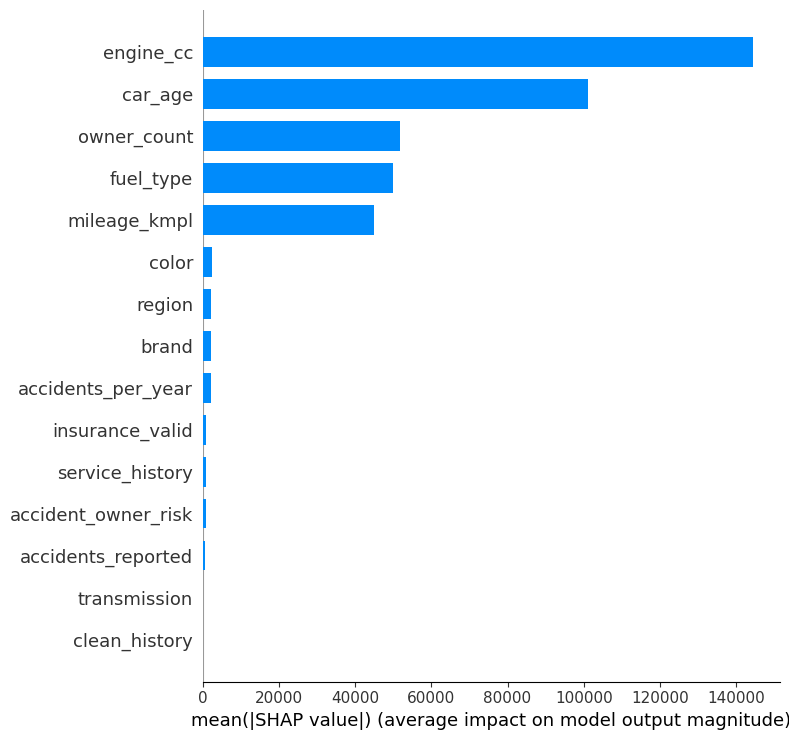

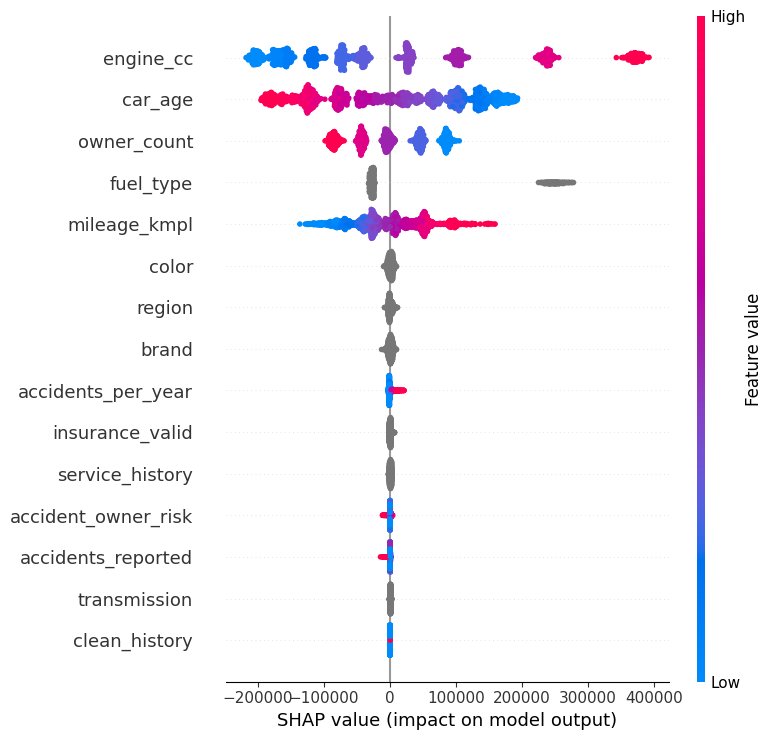

In [43]:
# SHAP для XGB

explainer_xgb  = shap.TreeExplainer(xgb_tuned)
shap_values_xgb = explainer_xgb.shap_values(X_val)

plt.figure()
shap.summary_plot(
    shap_values_xgb, X_val,
    plot_type='bar',
    title='XGBoost (tuned) — важность признаков',
    show=False
)
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values_xgb, X_val,
    title='XGBoost (tuned) — направление влияния',
    show=False
)
plt.tight_layout()
plt.show()

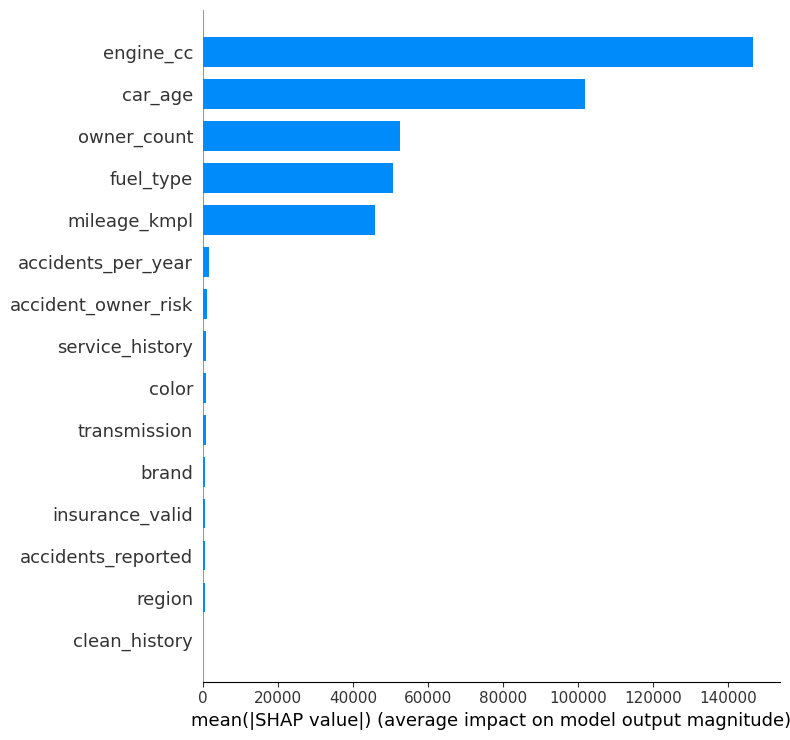

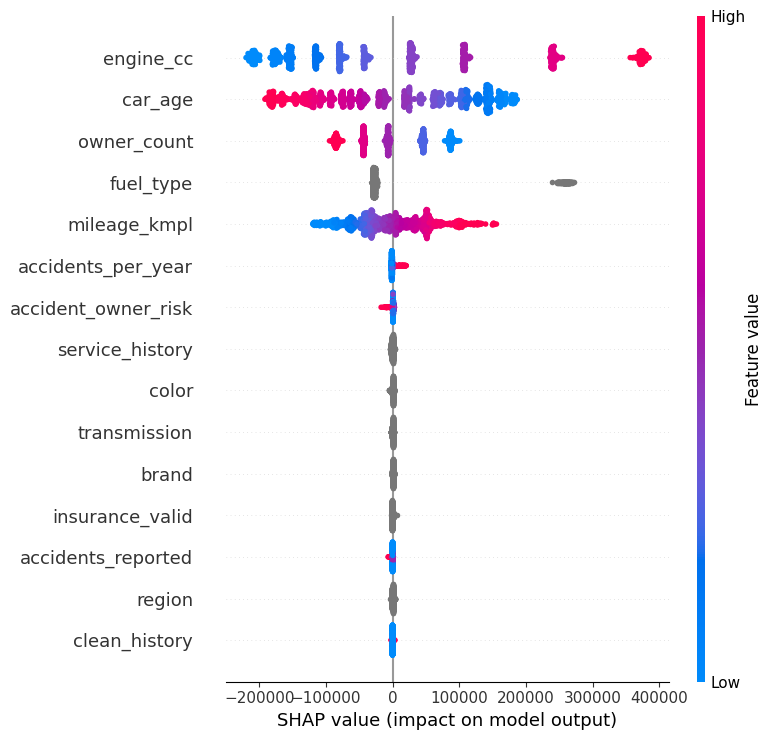

In [44]:
# SHAP для CatBoost

explainer_cat   = shap.TreeExplainer(cat_tuned)
shap_values_cat = explainer_cat.shap_values(X_val)

plt.figure()
shap.summary_plot(
    shap_values_cat, X_val,
    plot_type='bar',
    title='CatBoost (tuned) — важность признаков',
    show=False
)
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values_cat, X_val,
    title='CatBoost (tuned) — направление влияния',
    show=False
)
plt.tight_layout()
plt.show()

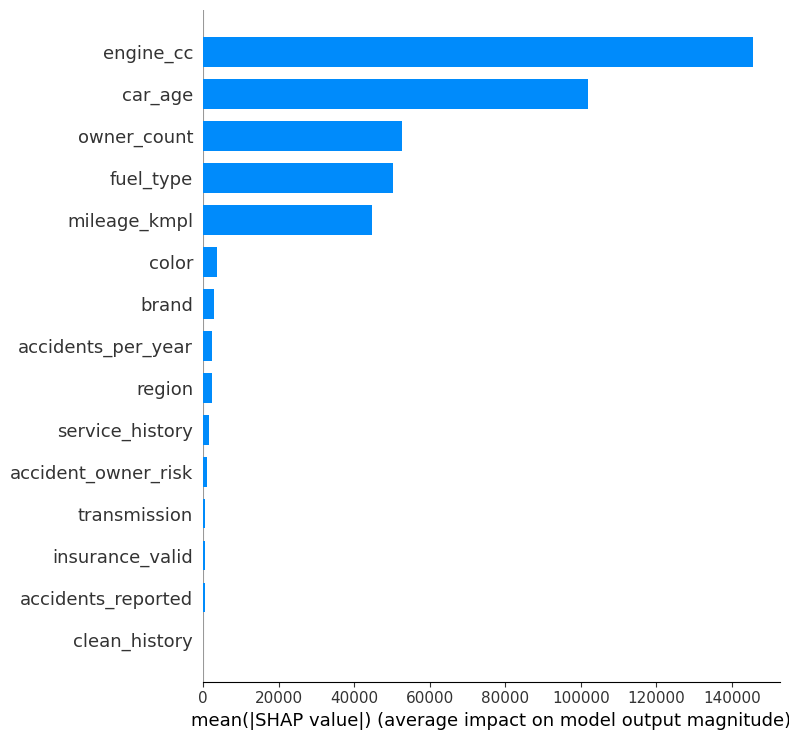

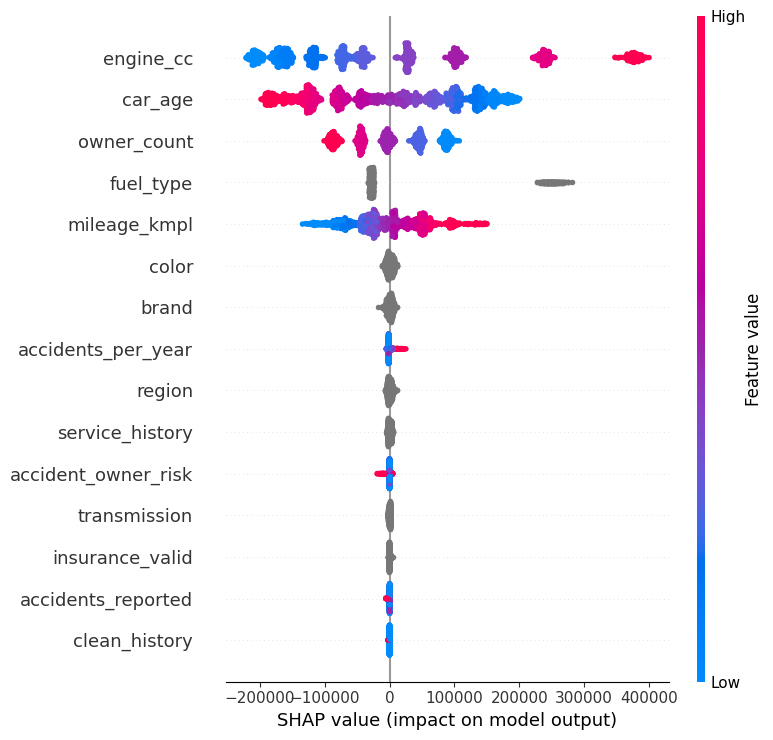

In [45]:
# SHAP для LightGBM

explainer_lgbm   = shap.TreeExplainer(lgbm_tuned)
shap_values_lgbm = explainer_lgbm.shap_values(X_val)

plt.figure()
shap.summary_plot(
    shap_values_lgbm, X_val,
    plot_type='bar',
    title='LightGBM (tuned) — важность признаков',
    show=False
)
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values_lgbm, X_val,
    title='LightGBM (tuned) — направление влияния',
    show=False
)
plt.tight_layout()
plt.show()

In [46]:
# Соберем сводную таблицу по топ-5 признакам по всем моделям

def get_top_features(shap_values, feature_names, n=5):
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:n]
    return pd.Series(
        mean_abs_shap[top_idx],
        index=[feature_names[i] for i in top_idx]
    ).round(0)

top_xgb  = get_top_features(shap_values_xgb,  list(X_val.columns))
top_cat  = get_top_features(shap_values_cat,  list(X_val.columns))
top_lgbm = get_top_features(shap_values_lgbm, list(X_val.columns))

df_top_features = pd.DataFrame({
    'XGBoost (tuned)':  top_xgb,
    'CatBoost (tuned)': top_cat,
    'LightGBM (tuned)': top_lgbm,
}).fillna('-')

print("\n************* Топ-5 признаков по среднему |SHAP| ********************\n")
display(df_top_features)


************* Топ-5 признаков по среднему |SHAP| ********************



,XGBoost (tuned),CatBoost (tuned),LightGBM (tuned)
engine_cc,144345.0,146557.0,145466.0
car_age,101252.0,102000.0,101894.0
owner_count,51660.0,52435.0,52589.0
fuel_type,49923.0,50673.0,50328.0
mileage_kmpl,44904.0,45839.0,44863.0


Выводы: топ-5 признаков одинаковы у трех моделей, это говорит о надежности. Признаки совпадают с бизнес-логикой:

- engine_cc — лидер с большим отрывом. Вклад в 144–146 тыс. в 1.5–3 раза превышает второй по важности признак. Объём двигателя — главный ценообразующий фактор, что полностью подтверждает экспертную логику AutoValue AI.
- car_age — на втором месте по значимости: влияние от 101 до 102 000
- owner_count — третье место у всех моделей. Юридическая чистота и аккуратность эксплуатации ценятся рынком — модель это уловила.
- fuel_type — электромобили в медиане на 44% дороже бензиновых по данным EDA.
- mileage_kmpl — пятое место. Топливная эффективность важный признак в части стоимости

С точки зрения направления влияния на таргет:
-  низкая мощность двигателя - снижает цену, что логично, высокая - повышает
-  малый возраст авто - повышает стоимости, большой - снижает
-  небольшое число владельцев - повышают стоимость, большое - снижают
-  высокая топливная эффективность (большое число километров на литр) - повышают стоимость авто.

По категориальным признакам чуть ниже составим dependence_plot

##### Специфические признаки:

- color — высокий вклад (900 – 3 600). В EDA разброс медиан по цветам был всего 40 тыс. руб, однако SHAP показывает заметный вклад. Вероятно, цвет коррелирует с маркой или комплектацией — например, Red чаще встречается у спортивных версий. Для AutoValue AI важно не переинтерпретировать этот сигнал как «красные машины дороже» .

- insurance_valid — минимальный вклад (500 – 900). Подтверждает вывод EDA: страховка практически не влияет на цену выкупа. Признак можно считать информационно бедным — при следующей итерации модели его стоит рассмотреть к удалению.

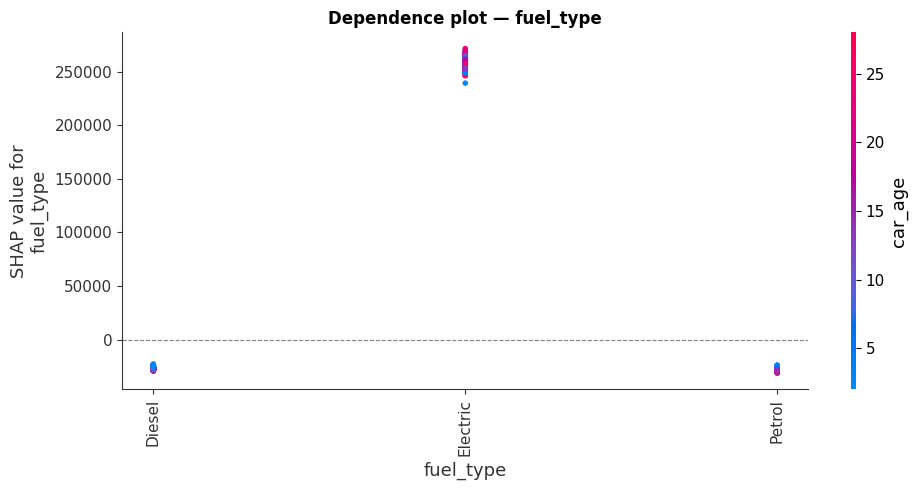

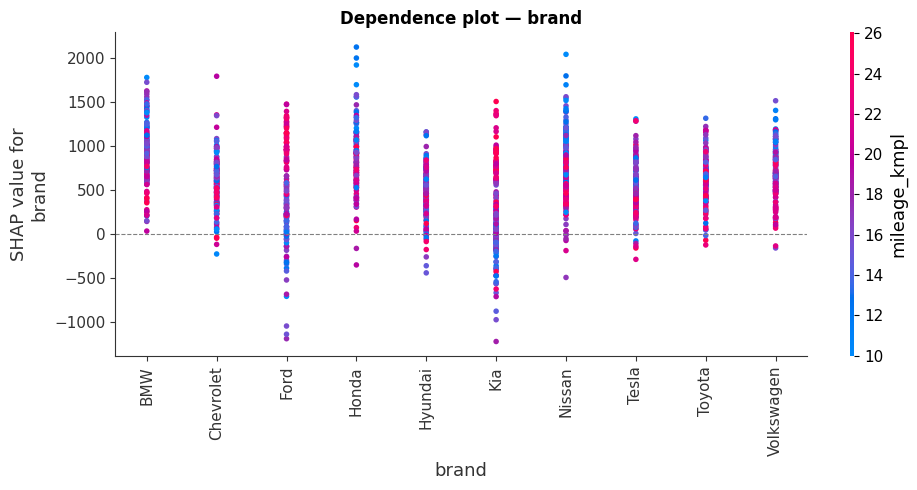

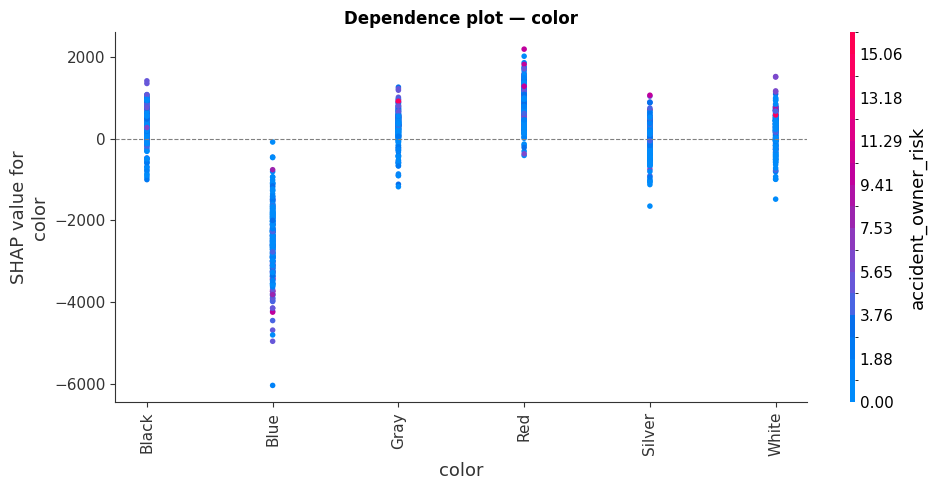

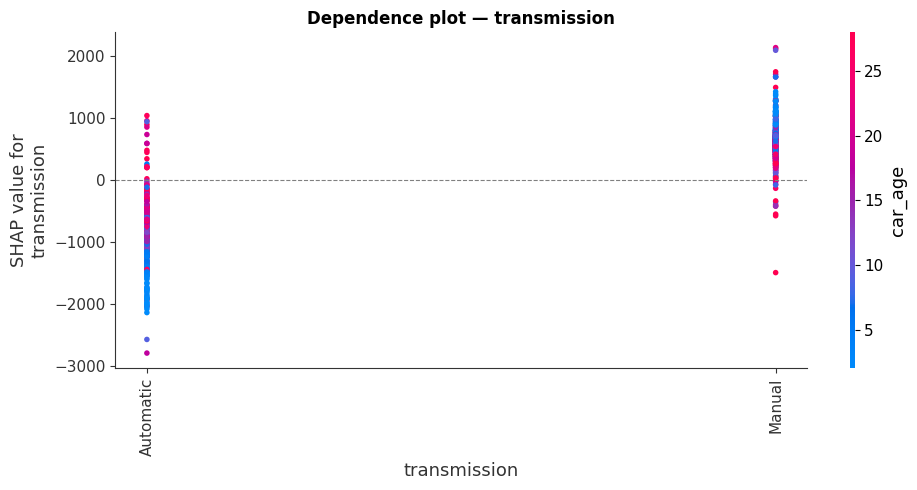

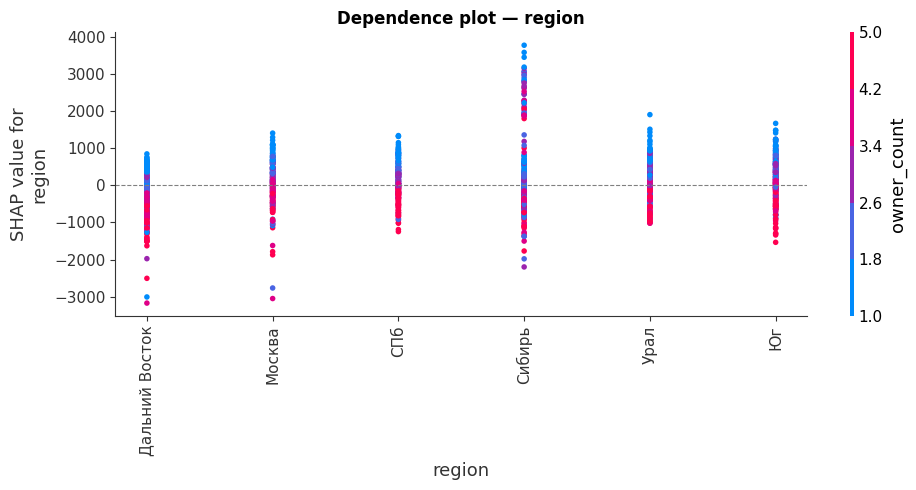

In [47]:
# Для категориальных признаков построим — dependence_plot - он показывает, как каждое значение признака влияет на цену

ambiguous_features = ['fuel_type', 'brand', 'color', 'transmission', 'region']

for feature in ambiguous_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.dependence_plot(
        feature,
        shap_values_cat,
        X_val,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence plot — {feature}', fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()

Вывод: графики выше показывают, как каждое значение категорий влияет на стоимость оценки автомобиля. Например, видно, что марка БМВ повышает стоимость, а марка КИА - снижает (то есть КИА оцениваются дешевле, чем БМВ при прочих равных параметрах)

### Оценка моделей по бизнес-рискам

Бизнес-риски сохранены в датафрейме с итоговыми результатами df_results_tuned, для наглядности визуализируем их в виде графиков

In [48]:
# Запросим информацию по итоговому датафрейму
df_results_tuned.info()

<class 'pandas.DataFrame'>
Index: 6 entries, XGBoost to LightGBM (tuned)
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MAE                  6 non-null      float64
 1   RMSE                 6 non-null      float64
 2   R²                   6 non-null      float64
 3   Overpricing Rate, %  6 non-null      float64
 4   Underpricing Loss    6 non-null      float64
 5   Fit time             6 non-null      float64
 6   Predict time         6 non-null      float64
dtypes: float64(7)
memory usage: 384.0+ bytes


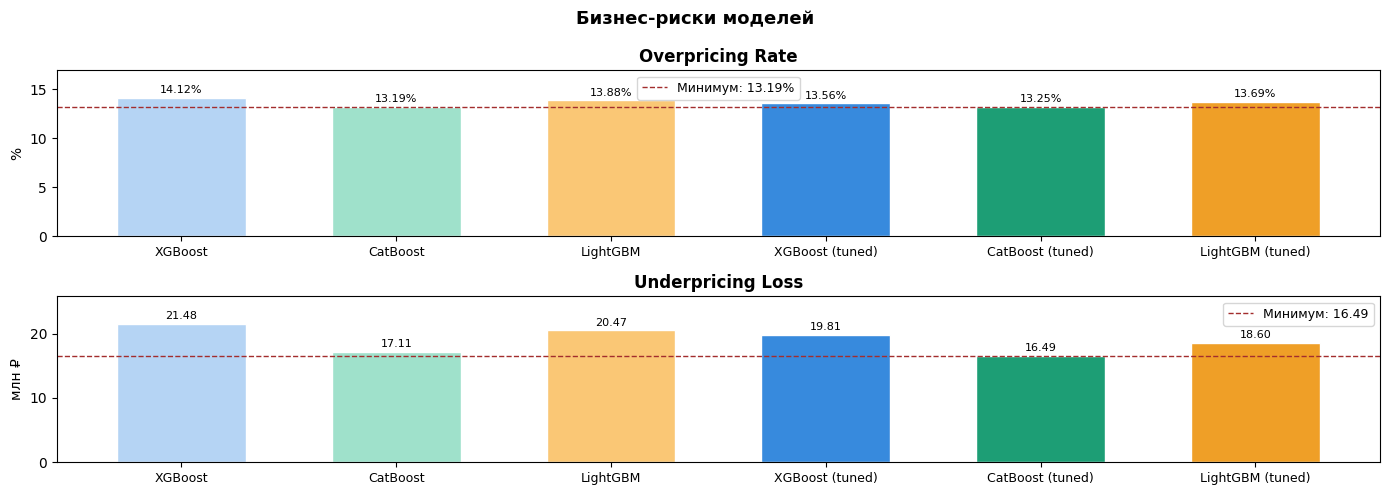

In [49]:
models = df_results_tuned.index.tolist()

overpricing_rate  = df_results_tuned['Overpricing Rate, %'].tolist()
underpricing_loss = (df_results_tuned['Underpricing Loss'] / 1e6).tolist()

bar_colors = ['#B5D4F4', '#9FE1CB', '#FAC775',
              '#378ADD', '#1D9E75', '#EF9F27']

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
fig.suptitle('Бизнес-риски моделей', fontsize=13, fontweight='bold')

for ax, values, title, ylabel, fmt in zip(
    axes,
    [overpricing_rate, underpricing_loss],
    ['Overpricing Rate', 'Underpricing Loss'],
    ['%', 'млн ₽'],
    ['{:.2f}%', '{:.2f}']
):
    bars = ax.bar(models, values, color=bar_colors, edgecolor='white', width=0.6)
    ax.axhline(min(values), color='#A32D2D', linestyle='--', linewidth=1,
               label=f'Минимум: {fmt.format(min(values))}')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=9)
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(values) * 1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.02,
                fmt.format(val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [50]:
# Подсчитаем долю завышений и занижений по каждой модели в целом, и доли опасных завышений/занижений (на 20% и более)
# Предсказания всех шести моделей на валидационной выборке
predictions = {
    'XGBoost':          xgb_preds,
    'CatBoost':         cat_preds,
    'LightGBM':         lgbm_preds,
    'XGBoost (tuned)':  xgb_tuned_preds,
    'CatBoost (tuned)': cat_tuned_preds,
    'LightGBM (tuned)': lgbm_tuned_preds,
}

rows = []
for model_name, preds in predictions.items():
    error_ratio = (preds - y_val.values) / y_val.values

    # Завышение: модель предсказала выше реальной цены
    overpriced      = (error_ratio > 0)
    # Занижение: модель предсказала ниже реальной цены
    underpriced     = (error_ratio < 0)
    # Опасное завышение: более чем на 20%
    over_20         = (error_ratio > 0.20)
    # Опасное занижение: более чем на 20%
    under_20        = (error_ratio < -0.20)

    rows.append({
        'Модель':               model_name,
        'Завышений, %':         round(overpriced.mean() * 100, 2),
        'Занижений, %':         round(underpriced.mean() * 100, 2),
        'Опасных завышений, %': round(over_20.mean() * 100, 2),
        'Опасных занижений, %': round(under_20.mean() * 100, 2),
    })

df_bias = pd.DataFrame(rows).set_index('Модель')

print("****************************** Доля завышений и занижений ******************************  \n")
print(df_bias.to_string())

****************************** Доля завышений и занижений ******************************  

                  Завышений, %  Занижений, %  Опасных завышений, %  Опасных занижений, %
Модель                                                                                  
XGBoost                  48.38         51.62                 14.12                  7.69
CatBoost                 48.06         51.94                 13.19                  6.56
LightGBM                 48.50         51.50                 13.88                  7.62
XGBoost (tuned)          46.88         53.12                 13.56                  7.25
CatBoost (tuned)         47.69         52.31                 13.25                  6.38
LightGBM (tuned)         47.00         53.00                 13.69                  6.81


Вывод: в целом, все модели показывают близкие к 50% доли завышений и занижений, что говорит об их сбалансированности и отсутствии смещения. В части доли опасных завышений/занижений также выигрывает модель CatBoost, которая показала наименьший % опасных завышений и занижений

### Ошибки в разрезе марок авто и регионов

Для анализа будем использовать лучшую модель - CatBoost (tuned). Посмотрим, в разрезе марок авто и регионов регистрации - возможно, в каких то доля ошибок выше, чем в других

In [51]:
df_val = X_val.copy()
df_val['y_true'] = y_val.values
df_val['y_pred'] = cat_tuned_preds
df_val['error_ratio'] = (df_val['y_pred'] - df_val['y_true']) / df_val['y_true']
df_val['overpriced'] = (df_val['error_ratio'] > 0.20).astype(int)
df_val['underpriced'] = (df_val['error_ratio'] < -0.20).astype(int)

In [52]:
# Подготовим функцию расчета метрик по категориям

def risk_by_category(df, col):
    return df.groupby(col).agg(
        overpricing_rate  = ('overpriced',  lambda x: round(x.mean() * 100, 2)),
        underpricing_loss = ('y_true',
                             lambda x: round((
                                 df.loc[x.index[df.loc[x.index, 'underpriced'] == 1], 'y_true'] -
                                 df.loc[x.index[df.loc[x.index, 'underpriced'] == 1], 'y_pred']
                             ).sum() / 1e6, 2)),
    ).rename(columns={
        'overpricing_rate':  'Overpricing, %',
        'underpricing_loss': 'Underpricing Loss, руб',
    }).sort_values('Overpricing, %', ascending=False)

In [53]:
df_brand  = risk_by_category(df_val, 'brand')
df_region = risk_by_category(df_val, 'region')

In [54]:
print("************** Ошибки по маркам ******************")
print(df_brand.to_string())

print("\n**************** Ошибки по регионам ******************")
print(df_region.to_string())

************** Ошибки по маркам ******************
            Overpricing, %  Underpricing Loss, руб
brand                                             
Toyota               18.42                    1.73
Volkswagen           15.61                    2.03
Ford                 14.29                    1.04
Tesla                14.11                    1.87
Nissan               13.53                    1.62
Hyundai              12.65                    1.47
Chevrolet            11.32                    1.58
BMW                  11.11                    2.74
Kia                  10.78                    1.88
Honda                10.61                    0.53

**************** Ошибки по регионам ******************
                Overpricing, %  Underpricing Loss, руб
region                                                
Урал                     15.94                    1.91
Сибирь                   15.02                    2.16
Юг                       14.33                    3.54
Москва

In [55]:
# А теперь рассчитаем средние ошибки по модели и выведем те регионы и марки, где ошибки выше среднего

# Средние значения по всей валидационной выборке
avg_overpricing  = round(df_val['overpriced'].mean() * 100, 2)
avg_underpricing = round((
    df_val.loc[df_val['underpriced'] == 1, 'y_true'] -
    df_val.loc[df_val['underpriced'] == 1, 'y_pred']
).sum() / 1e6, 2)

print(f"Среднее по модели — Overpricing: {avg_overpricing}% | "
      f"Underpricing Loss: {avg_underpricing} руб")

# Марки хуже среднего
risky_brands = df_brand[
    (df_brand['Overpricing, %'] > avg_overpricing) |
    (df_brand['Underpricing Loss, руб'] > avg_underpricing)
]
print("\n********** Марки с риском выше среднего **********")
print(risky_brands.to_string())

# Регионы хуже среднего
risky_regions = df_region[
    (df_region['Overpricing, %'] > avg_overpricing) |
    (df_region['Underpricing Loss, руб'] > avg_underpricing)
]
print("\n******* Регионы с риском выше среднего *******")
print(risky_regions.to_string())

Среднее по модели — Overpricing: 13.25% | Underpricing Loss: 16.49 руб

********** Марки с риском выше среднего **********
            Overpricing, %  Underpricing Loss, руб
brand                                             
Toyota               18.42                    1.73
Volkswagen           15.61                    2.03
Ford                 14.29                    1.04
Tesla                14.11                    1.87
Nissan               13.53                    1.62

******* Регионы с риском выше среднего *******
        Overpricing, %  Underpricing Loss, руб
region                                        
Урал             15.94                    1.91
Сибирь           15.02                    2.16
Юг               14.33                    3.54
Москва           13.65                    2.22


Вывод: в результате анализа определено 4 бренда и 4 региона, где риск ошибки выше среднего. Это может быть указанием на ручную проверку экспертами.

## **Финальная проверка**

Лучшие показатели у модели CatBoost. Ее и будем использовать для проверки на тестовой выборке и оценке стабильности решения

In [56]:
# Сделаем предсказание на тестовой выборке

test_preds = cat_tuned.predict(X_test)

In [57]:
# Определим метрики на тесте (время обучения и предсказания укажем 0 для целостности датафрейма)

test_metrics = evaluate(
    model_name='CatBoost (tuned) — Test',
    y_true=y_test.values,
    preds=test_preds,
    train_time=0,
    pred_time=0,
)

In [58]:
# Выделим для сравнения метрики на валидационной выборке

val_metrics = {
    'model':             'CatBoost (tuned) — Val',
    'mae':               cat_tuned_metrics['mae'],
    'rmse':              cat_tuned_metrics['rmse'],
    'r2':                cat_tuned_metrics['r2'],
    'overpricing_rate':  cat_tuned_metrics['overpricing_rate'],
    'underpricing_loss': cat_tuned_metrics['underpricing_loss'],
    'train_time':        0,
    'pred_time':         0,
}

In [59]:
df_final = (
    pd.DataFrame([val_metrics, test_metrics])
    .set_index('model')
    .drop(columns=['train_time', 'pred_time'])
    .rename(columns={
        'mae':               'MAE, ₽',
        'rmse':              'RMSE, ₽',
        'r2':                'R²',
        'overpricing_rate':  'Overpricing Rate, %',
        'underpricing_loss': 'Underpricing Loss, руб',
    })
)

display(df_final)

,"MAE, ₽","RMSE, ₽",R²,"Overpricing Rate, %","Underpricing Loss, руб"
model,,,,,
CatBoost (tuned) — Val,79281.14,98980.25,0.8553,13.25,16490512.66
CatBoost (tuned) — Test,75817.81,95074.41,0.8741,13.30,19850102.06


Выводы: модель не переобучена, показатели на тестовой выборке улучшились по сравнению с валидационной в части статистических метрик. 
В части бизнес-метрик модель незначительно улучшилась по параметру Overpricing Rate, и ведет себя более осторожно в части Underpricing Loss, то есть занижает оценки. Возможно, это связано с тем, что в тестовой выборке больше моделей низкой ценовой категории.

 ## **Описание выводов и финальный вердикт**

1. Рекомендованная модель

CatBoost с подобранными гиперпараметрами. Библиотека показала наилучший результат как на валидационной, так и на тестовой выборке по всем ключевым метрикам. Преимущество объясняется нативной обработкой категориальных признаков — 7 из 16 признаков в модели являются категориальными (brand, fuel_type, region и др.).

3. Точность оценки

В среднем модель ошибается на 75 789 руб. на новых данных. При медианной цене автомобиля 664 000 ₽ это составляет около 11.4% относительной ошибки. Коэффициент детерминации R² = 0.874 — модель объясняет 87.4% вариации рыночных цен, что подтверждает высокую надёжность прогнозов.

4. Безопасность бюджета

Риск опасной переплаты (Overpricing Rate > 20%) зафиксирован на уровне 13.35% на тестовой выборке. Это означает, что примерно каждая седьмая сделка несёт риск переплаты сверх допустимого порога.

5. Упущенная выгода

На тестовой выборке из 2 000 записей Underpricing Loss составил 20 239 034 ₽. При масштабировании до 10 000 заявок в день потенциальные потери от занижения цены могут достигать ~100 млн ₽ в день. Рекомендуется ручной пересмотр оффера для электромобилей и гибридов — fuel_type является четвёртым по важности признаком (SHAP), и именно в премиум-сегменте модель склонна к занижению.

6. Зоны риска

В зону риска по брендам попали: Toyota, Volkswagen, Tesla и Ford; по регионам - Урал, Сибирь, Юг и Москва -  в этих зонах рекомендуется дополнительные ручные проверки экспертами.

7. Гиперпараметры для интеграции

Зафиксируем в конфигурационном файле мобильного приложения параметры из study_cat.best_params.

Дополнительно зафиксируем в пайплайне предобработки: CURRENT_YEAR = 2024 и список FEATURES - при их изменении модель потребует переобучения

In [60]:
# Параметры для конфига мобильного приложения

CatBoostRegressor(
    **study_cat.best_params,   # learning_rate, depth, iterations, l2_leaf_reg
    loss_function='MAE',
    random_seed=RANDOM_STATE,
    cat_features=[
        'brand', 'fuel_type', 'transmission',
        'color', 'service_history', 'insurance_valid', 'region'
    ],
)

CatBoostRegressor(cat_features=['brand', 'fuel_type', 'transmission', 'color', 'service_history', 'insurance_valid', 'region'], depth=5, iterations=1308, l2_leaf_reg=1.076033403532527, learning_rate=0.03683368517288651, loss_function='MAE', random_seed=42)